# 03 · Recover a real raster batch after an interruption

Use sixteen Sentinel-2 windows to demonstrate durable progress, verified skipping, corruption recovery, and invalidation when a result-affecting parameter changes.

[Notebook index](README.md) · [Companion article](../docs/articles/resumable-workflows.md) · [Data sources and licences](../docs/DATA_SOURCES.md)

Run every cell from top to bottom in the locked Python 3.12 environment. The first run downloads the required public data pack and checks its SHA-256. Generated artifacts remain in the ignored `outputs/` directory.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython import get_ipython
from IPython.display import display

from geoai_portfolio.io import ensure_data, workspace

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.figsize": (10, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 9,
        "axes.titlesize": 11,
        "font.size": 10,
        "savefig.bbox": "tight",
    }
)
pd.set_option("display.precision", 4)

In [2]:
import tempfile

from geoai_portfolio.workflows import run_windows

data = ensure_data("satellite")
out = workspace("03-recovery")
scene, scl = data / "before.tif", data / "before-scl.tif"

## Define a task identity

Each task records SHA-256 hashes of both input rasters, the algorithm version, the pixel
window and an NDVI threshold. A completed task is reusable only if its output checksum
still matches. The manifest is replaced atomically after the output is complete.
This example has one writer and local storage; it is not a distributed queue.
A temporary directory makes repeated Run All executions independent.

In [3]:
events = []
with tempfile.TemporaryDirectory(prefix="batch-", dir=out) as temporary:
    batch = Path(temporary)
    first = run_windows(scene, scl, batch, fail_at=5)
    assert first["failed"] == 5 and len(first["executed"]) == 5
    events.append({"stage": "controlled failure", **first})
    second = run_windows(scene, scl, batch)
    assert second["skipped"] == list(range(5)) and second["failed"] is None
    events.append({"stage": "resume", **second})
    # Corrupt only an artifact created in this dedicated temporary directory.
    (batch / "window-002.json").write_text("damaged", encoding="utf-8")
    repaired = run_windows(scene, scl, batch)
    assert repaired["executed"] == [2]
    events.append({"stage": "repair damaged output", **repaired})
    changed = run_windows(scene, scl, batch, threshold=0.6)
    assert len(changed["executed"]) == 16 and not changed["skipped"]
    events.append({"stage": "changed threshold", **changed})
    values = pd.DataFrame([json.loads(p.read_text()) for p in sorted(batch.glob("window-*.json"))])
display(
    pd.DataFrame(
        [
            {**row, "executed": len(row["executed"]), "skipped": len(row["skipped"])}
            for row in events
        ]
    )
)
display(values[["window", "valid_pixels", "mean_ndvi", "above_threshold"]].head(8))

,stage,executed,skipped,failed
0,controlled failure,5,0,5.0
1,resume,11,5,NaN
2,repair damaged output,1,15,NaN
3,changed threshold,16,0,NaN


,window,valid_pixels,mean_ndvi,above_threshold
0,0,16384,0.6099,9553
1,1,16384,0.7466,14917
2,2,16383,0.7237,13163
3,3,16380,0.6196,9779
4,4,16294,0.6552,11085
5,5,16371,0.7568,14289
6,6,16254,0.7633,14871
7,7,16384,0.6861,13103


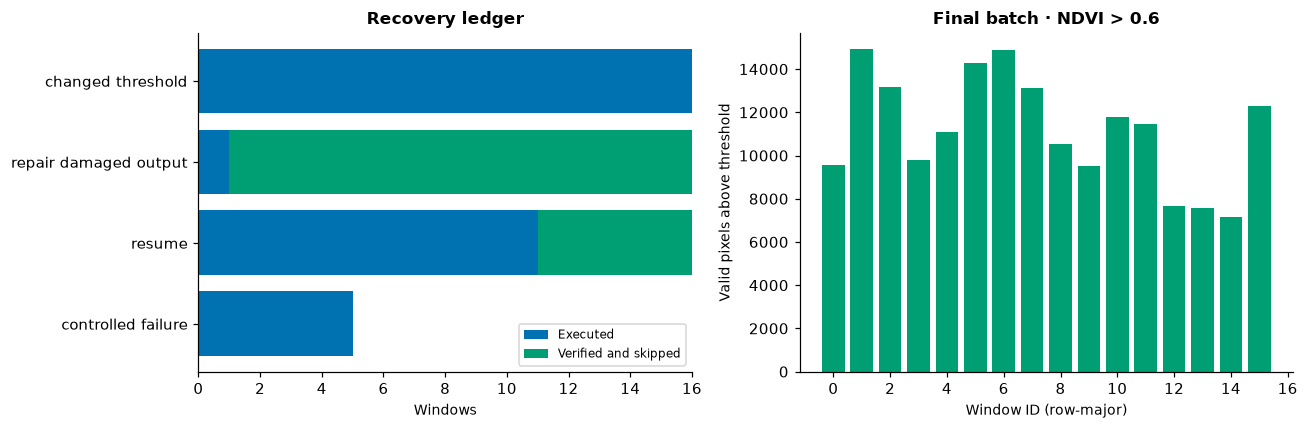

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = [row["stage"] for row in events]
executed = [len(row["executed"]) for row in events]
skipped = [len(row["skipped"]) for row in events]
axes[0].barh(labels, executed, color="#0072B2", label="Executed")
axes[0].barh(labels, skipped, left=executed, color="#009E73", label="Verified and skipped")
axes[0].set(xlabel="Windows", title="Recovery ledger")
axes[0].legend(fontsize=8)
axes[1].bar(values.window, values.above_threshold, color="#009E73")
axes[1].set(
    title="Final batch · NDVI > 0.6",
    xlabel="Window ID (row-major)",
    ylabel="Valid pixels above threshold",
)
plt.tight_layout()
plt.show()

## Interpret the execution evidence

A saved completion flag alone is insufficient: the damaged task must run again.
Changing 0.4 to 0.6 invalidates all sixteen tasks because their numerical outputs depend
on that parameter. A source-file change has the same effect through its hash. A valid
zero count remains a successful result; absence of an output never means zero vegetation.

The threshold is an illustrative spectral cutoff, not a calibrated forest-area classifier.
For durable multi-worker execution, extend the design with locks or transactional claims,
atomic object publication, and explicit retry ownership before introducing concurrency.